In [1]:
from utils import get_df

df_dp = get_df()
df_dp.head()

,ID,Method,Model,question,Question-only,target_answer,response,is_correct,input_tokens,output_tokens,total_tokens,reasoning,Error Class,Type
0,chal-736,Direct Prompting,ollama/qwen3_1.7b,Winter is almost here and most animals are mig...,How many more bird families flew away to afric...,27,"<think>\nOkay, let's see. The problem is about...",True,491,273,764,"[AI]: <think>\nOkay, let's see. The problem is...",NaN,Subtraction
1,chal-162,Direct Prompting,ollama/qwen3_1.7b,Paige raised 7 goldfish and 12 catfish in the ...,How many fishes disappeared?,4,"<think>\nOkay, let's see. The problem says Pai...",True,1107,292,1399,"[AI]: <think>\nOkay, let's see. Paige started ...",NaN,Subtraction
2,chal-349,Direct Prompting,ollama/qwen3_1.7b,Marco and his dad went strawberry picking. Tog...,How much did his dad's strawberries weigh now?,16,"<think>\nOkay, let's break down the problem st...",True,1398,655,2053,"[AI]: <think>\nOkay, let's see. Marco and his ...",NaN,Addition
3,chal-390,Direct Prompting,ollama/qwen3_1.7b,Debby bought 200 water bottles and 256 soda bo...,How many days would the soda bottles last?,64,"<think>\nOkay, let's see. Debby bought 200 wat...",True,477,306,783,"[AI]: <think>\nOkay, let's see. Debby bought 2...",NaN,Common-Division
4,chal-781,Direct Prompting,ollama/qwen3_1.7b,There were 106 dollars in Olivia's wallet. Aft...,How much did she spend at the supermarket?,31,"<think>\nOkay, let's see. The problem says Oli...",True,1270,552,1822,"[AI]: <think>\nOkay, let's see. Olivia had $10...",NaN,Subtraction


In [2]:
df_dp.groupby("Model").agg({
    "is_correct": "sum",
})

,is_correct
Model,
ollama/qwen3_1.7b,279


In [3]:
from chromadb import PersistentClient
import ollama

client = PersistentClient(path="chroma_db")
collection = client.get_or_create_collection(name="SVAMP_semantic_analysis")

entries = {}
for _, row in df_dp.iterrows():
    if row["ID"] not in entries:
        entries[row["ID"]] = row["question"]

print(entries)

{'chal-736': 'Winter is almost here and most animals are migrating to warmer countries. There are 41 bird families living near the mountain. If 35 bird families flew away to asia and 62 bird families flew away to africa How many more bird families flew away to africa than those that flew away to asia?', 'chal-162': 'Paige raised 7 goldfish and 12 catfish in the pond but stray cats loved eating them. Now she has 15 left. How many fishes disappeared?', 'chal-349': "Marco and his dad went strawberry picking. Together they collected strawberries that weighed 22 pounds. On the way back Marco ' dad found 30 more pounds of strawberries. Marco's strawberries now weighed 36 pounds. How much did his dad's strawberries weigh now?", 'chal-390': 'Debby bought 200 water bottles and 256 soda bottles when they were on sale. If she drank 312 water bottles and 4 soda bottles a day How many days would the soda bottles last?', 'chal-781': "There were 106 dollars in Olivia's wallet. After she visited a sup

In [4]:
from tqdm import tqdm

for idx, question in tqdm(entries.items(), total=len(entries)):
    emb = ollama.embed(
        model="all-minilm:33m",
        input=question
    )
    embeddings = emb.embeddings[0]
    collection.upsert(
        documents=[question],
        embeddings=[embeddings],
        metadatas=None,
        ids=[str(idx)]
    )

  0%|          | 0/298 [00:00<?, ?it/s]

100%|██████████| 298/298 [00:14<00:00, 20.88it/s]


In [5]:
import numpy as np
all_items = collection.get(include=['embeddings'])
embeddings = np.array(all_items['embeddings'])

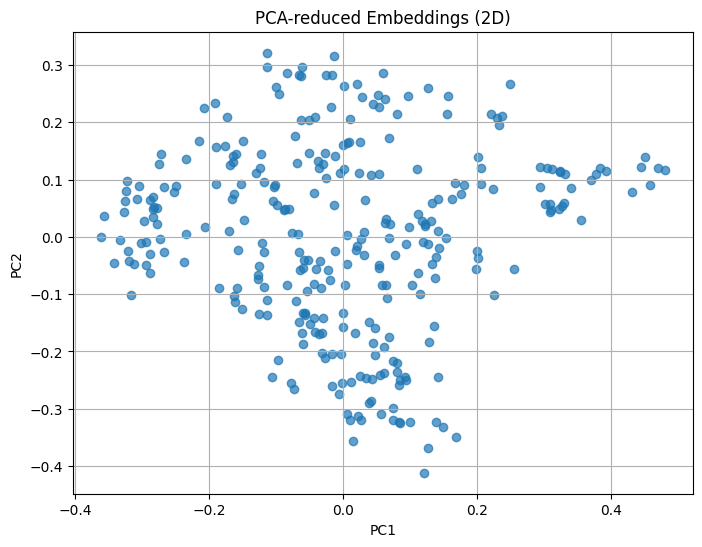

In [6]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import chromadb

# 3. Apply PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 4. (Optional) Visualize
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.7)
plt.title("PCA-reduced Embeddings (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [7]:
from sklearn.cluster import KMeans

# 1. Apply K-Means clustering
num_clusters = 52  # You can adjust the number of clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

In [8]:
# Print out some clusters and their corresponding items
entry_keys = list(entries.keys())  # Get the original keys from entries
def get_original_key(idx):
    return entry_keys[idx]  # Map numerical index to original key

In [9]:
cluster_data = {}
cluster_mapping= {}
for cluster in range(num_clusters):
    print(f"Cluster {cluster}:")
    cluster_data[cluster] = []
    cluster_indices = np.where(labels == cluster)[0]
    for idx in cluster_indices:  # Print up to 5 items per cluster
        original_key = get_original_key(idx)
        print(f"  Item {original_key}: {entries[original_key]}")
        cluster_data[cluster].append(original_key)
        cluster_mapping[original_key] = cluster
    print("\n")

Cluster 0:
  Item chal-891: A farmer had 177 tomatoes and 12 potatoes in his garden. If he picked 53 tomatoes How many tomatoes and potatoes does he have left?
  Item chal-136: A farmer had 175 tomatoes and 77 potatoes in his garden. If he picked 172 potatoes How many tomatoes and potatoes does he have left?
  Item chal-128: A farmer had 171 tomatoes in his garden. If he picked 134 of them yesterday and 30 today. How many will he have left after today?


Cluster 1:
  Item chal-544: A book has 3 chapters. The first chapter is 91 pages long the second chapter is 23 pages long and the third chapter is 25 pages long. How many more pages does the first chapter have than the second chapter?
  Item chal-380: Rachel had to complete 5 pages of math homework and 2 pages of reading homework. How many more pages of math homework than reading homework did she have?
  Item chal-254: Rachel had to complete 10 pages of math homework. If she had to complete 3 more pages of reading homework than math ho

In [10]:
df_dp['Cluster'] = df_dp['ID'].map(cluster_mapping)
cluster_analysis = df_dp.groupby(['Cluster', 'Model']).agg({'is_correct': 'sum'}).reset_index()
cluster_analysis.rename(columns={'is_correct': 'Correct_Count'}, inplace=True)
cluster_analysis["Cluster-len"] = cluster_analysis['Cluster'].map(lambda x: len(cluster_data[x]) if x in cluster_data else 0)
cluster_analysis["Wrong_Count"] = cluster_analysis["Cluster-len"] - cluster_analysis["Correct_Count"]
cluster_analysis["Correct_Score"] = cluster_analysis['Correct_Count'] / cluster_analysis["Cluster-len"] * 100
cluster_analysis["Wrong_Score"] = cluster_analysis['Wrong_Count'] / cluster_analysis["Cluster-len"] * 100
# Display the results
cluster_analysis.head()

,Cluster,Model,Correct_Count,Cluster-len,Wrong_Count,Correct_Score,Wrong_Score
0,0,ollama/qwen3_1.7b,2,3,1,66.666667,33.333333
1,1,ollama/qwen3_1.7b,3,3,0,100.0,0.0
2,2,ollama/qwen3_1.7b,8,10,2,80.0,20.0
3,3,ollama/qwen3_1.7b,7,7,0,100.0,0.0
4,4,ollama/qwen3_1.7b,6,6,0,100.0,0.0


In [11]:
# Pivot the cluster_analysis DataFrame to get clusters as rows and models as columns
cluster_pivot = cluster_analysis.pivot(index='Cluster', columns='Model', values='Wrong_Count')
# Display the new DataFrame
cluster_pivot.head(55)

Model,ollama/qwen3_1.7b
Cluster,
0,1
1,0
2,2
3,0
4,0
5,0
6,0
7,0
8,0


In [12]:
# Pivot the cluster_analysis DataFrame to get clusters as rows and models as columns
cluster_pivot = cluster_analysis.pivot(index='Cluster', columns='Model', values='Wrong_Score')
# Display the new DataFrame
cluster_pivot.head(55)

Model,ollama/qwen3_1.7b
Cluster,
0,33.333333
1,0.0
2,20.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
